In [ ]:
import pandas as pd
medical_df = pd.read_csv('Medical_insurance.csv')
medical_df
medical_df.info()
medical_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2772 non-null   int64  
 1   sex       2772 non-null   object 
 2   bmi       2772 non-null   float64
 3   children  2772 non-null   int64  
 4   smoker    2772 non-null   object 
 5   region    2772 non-null   object 
 6   charges   2772 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 151.7+ KB


,age,bmi,children,charges
count,2772.000000,2772.000000,2772.000000,2772.000000
mean,39.109668,30.701349,1.101732,13261.369959
std,14.081459,6.129449,1.214806,12151.768945
min,18.000000,15.960000,0.000000,1121.873900
25%,26.000000,26.220000,0.000000,4687.797000
50%,39.000000,30.447500,1.000000,9333.014350
75%,51.000000,34.770000,2.000000,16577.779500
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:
!pip install jovian --quiet


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.6/68.6 kB 2.1 MB/s eta 0:00:00


In [ ]:
import jovian
jovian.commit()

[jovian] Detected Colab notebook...
[jovian] jovian.commit() is no longer required on Google Colab. If you ran this notebook from Jovian, 
then just save this file in Colab using Ctrl+S/Cmd+S and it will be updated on Jovian. 
Also, you can also delete this cell, it's no longer necessary.


In [ ]:
!pip install plotly matplotlib seaborn --quiet

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:

import matplotlib
sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10,6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

In [ ]:
medical_df.age.describe()


,age
count,2772.000000
mean,39.109668
std,14.081459
min,18.000000
25%,26.000000
50%,39.000000
75%,51.000000
max,64.000000


In [ ]:
import plotly.express as px
fig = px.histogram(medical_df,x = 'age',marginal = "box",nbins=47,title = 'distribution of age',color_discrete_sequence=['blue'])
fig.update_layout(bargap = 0.15)
fig.show()

In [ ]:
fig = px.histogram(medical_df,x='bmi',marginal='box',color_discrete_sequence=['blue'],title = 'distribution of BMI')
fig.update_layout(bargap = 0.15)
fig.show()

In [ ]:
fig = px.histogram(medical_df,x='charges',marginal='box',color='smoker',color_discrete_sequence=['black','blue'],title = 'Annual medical charges')
fig.update_layout(bargap=0.15)
fig.show()

In [ ]:
fig = px.histogram(medical_df,x='charges',marginal='box',color='smoker',facet_col = 'sex',color_discrete_map={'yes':'black','no':'blue'},color_discrete_sequence=['black','blue','green'],title = 'Gender of the customer')
fig.update_layout(bargap=0.15)
fig.show()

In [ ]:
# medical_df.smoker.value_counts() this is only counts smoker and  non smoker
medical_df.groupby(['sex','smoker']).size()

sex     smoker
female  no        1134
        yes        232
male    no        1074
        yes        332
dtype: int64

In [ ]:
# px.histogram(medical_df,x='smoker',color='sex',title='smokers')both are same above and this

In [ ]:
fig = px.scatter(medical_df,x='age',y='charges',color='smoker',hover_data=['sex'],title='Age vs. Charges',color_discrete_map={'yes':'black','no':'blue'})
fig.update_traces(marker_size = 5)
fig.show()

In [ ]:
fig = px.scatter(medical_df,x='bmi',y='charges',color='smoker',hover_data=['sex'],title='BMI vs. Charges',color_discrete_map={'yes':'black','no':'blue'})
fig.update_traces(marker_size = 5)
fig.show()

In [ ]:
fig2 = px.violin(medical_df, y="charges", x="sex", box=True, points="all", color="sex", title="Charges vs Sex")
fig2.show()

In [ ]:
medical_df.charges.corr(medical_df.bmi) #relation between the smoker and charges it showa how much itis linked it is integer same

np.float64(0.19984604873978873)

In [ ]:
#if one integer and another is string then we get error we need to change it to sseries then we can use it
# smoker_values = {'no':0,'yes':1}
# smoker_numeric=medical_df.smoker.map(smoker_values)
# medical_df.charges.corr(smoker_numeric)


In [ ]:
# medical_df.corr()

In [ ]:
non_smoker_df = medical_df[medical_df.smoker=='no']


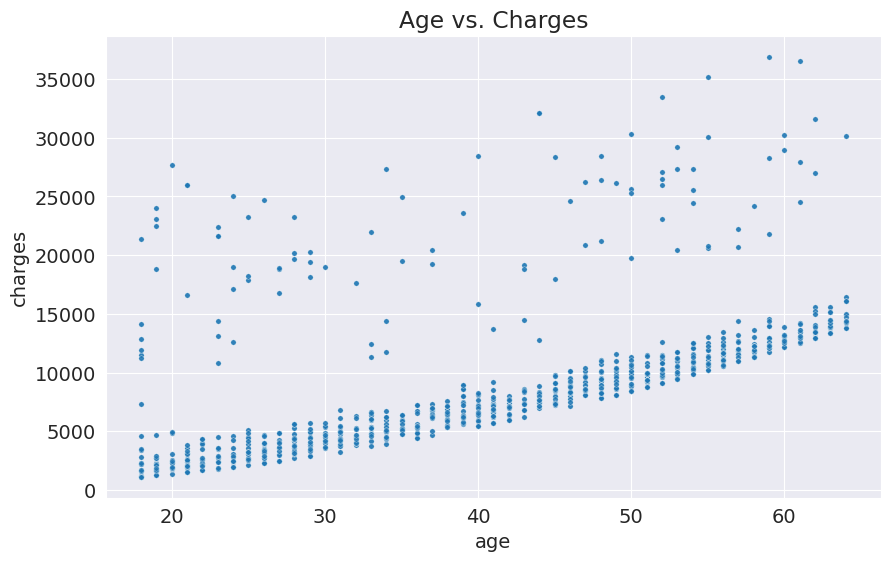

In [ ]:
plt.title('Age vs. Charges')
sns.scatterplot(data=non_smoker_df,x = 'age',y='charges',alpha=1,s=15);

In [ ]:
def estimate_charges(age,w,b):
  return w*age+b

In [ ]:
w=50
b=100

In [ ]:
estimate_charges(30,w,b)

1600

In [ ]:
ages = non_smoker_df.age
estimate_charges = estimate_charges(ages,w,b)


Text(0, 0.5, 'Charges in $')

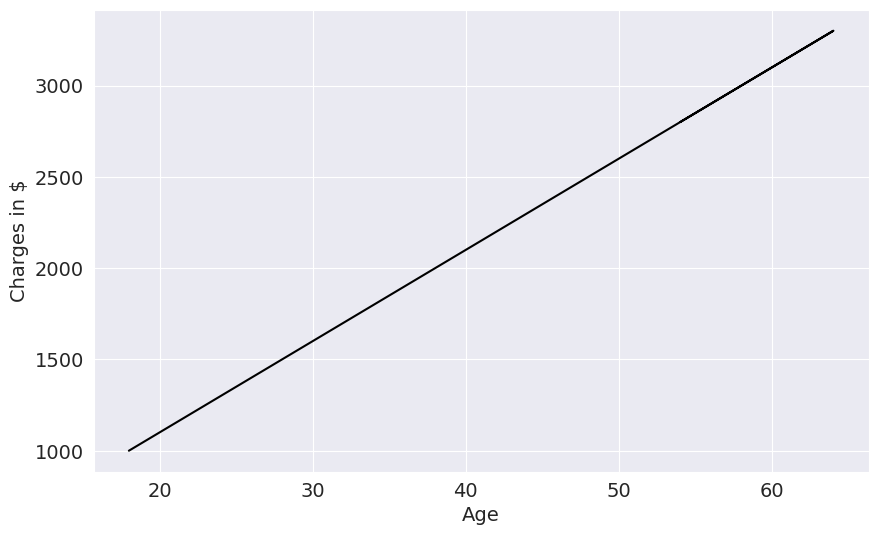

In [ ]:
plt.plot(ages,estimate_charges,color='black')
plt.xlabel('Age')
plt.ylabel('Charges in $')


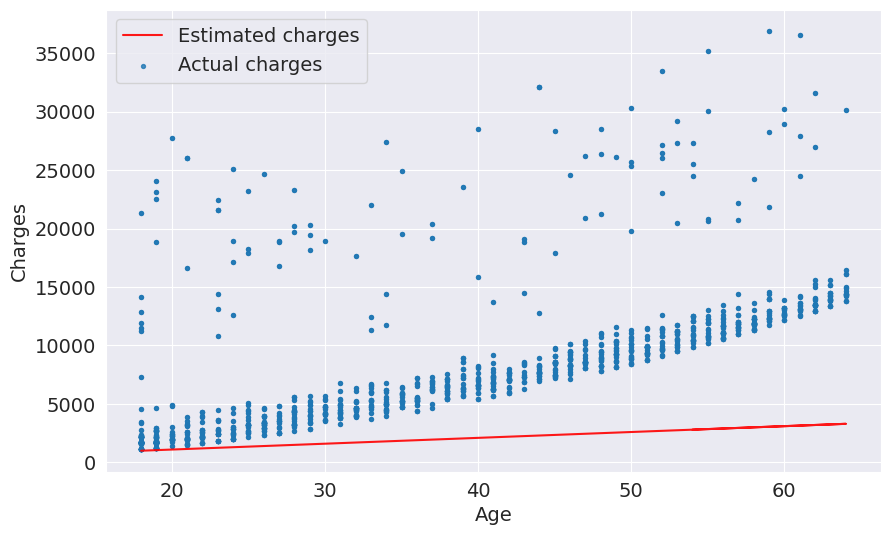

In [ ]:
target = non_smoker_df.charges
plt.plot(ages,estimate_charges,'red',alpha=0.9);
plt.scatter(ages,target,s=8,alpha=0.8)
plt.xlabel('Age')
plt.ylabel('Charges')
plt.legend(['Estimated charges','Actual charges'])

In [ ]:
def try_parameters(w,b):
  ages = non_smoker_df.age
  target = non_smoker_df.charges
  predicted = estimate_charges(ages,w,b)
  plt.plot(ages,predicted,'red',alpha=0.9);
  plt.scatter(ages,target,s=8,alpha=0.8)
  plt.xlabel('Age')
  plt.ylabel('Charges')
  plt.legend(['Estimated charges','Actual charges'])

In [ ]:
# # try_parameters(60,200)
# try_parameters(276,-2150)

In [ ]:
targets = non_smoker_df.charges
targets

,charges
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520
5,3756.62160
...,...
2766,1711.02680
2767,8569.86180
2768,2020.17700
2770,21595.38229


In [ ]:
predictions = estimate_charges
predictions


,age
1,1000
2,1500
3,1750
4,1700
5,1650
...,...
2766,1000
2767,2450
2768,1150
2770,1250


In [ ]:
!pip install numpy --quiet

In [ ]:
del estimate_charges


In [ ]:
def estimate_charges(age, w, b):
    return w * age + b


In [ ]:
import numpy as np
def rmse(targets,predictions):
  return np.sqrt(np.mean(np.square(target-predictions)))

In [ ]:
w = 50
b = 100

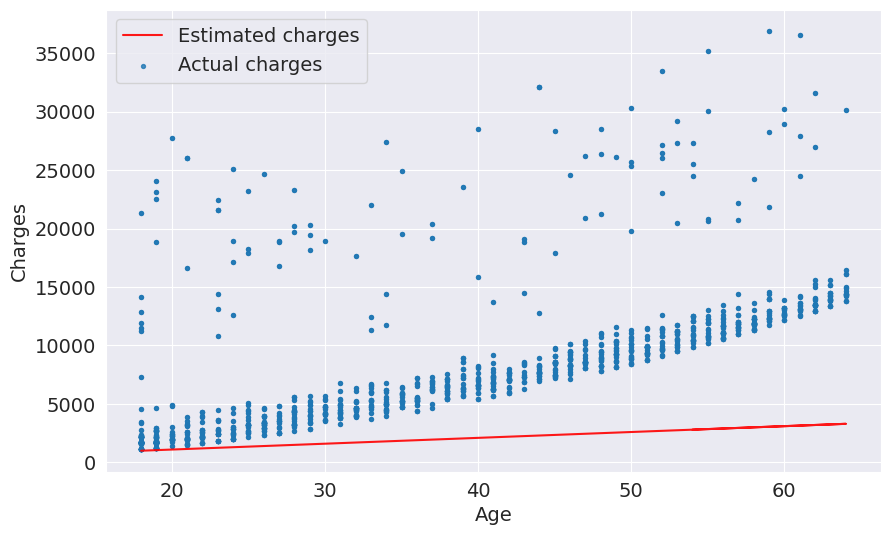

In [ ]:
try_parameters(w,b)

In [ ]:
targets=non_smoker_df['charges']
predicted = estimate_charges(non_smoker_df.age,w,b)
rmse(targets,predicted)

np.float64(8471.933919324138)

In [ ]:
def try_parameter(w,b):
  ages = non_smoker_df.age
  target = non_smoker_df['charges']
  predictions = estimate_charges(ages,w,b)
  plt.plot(ages,predictions,'r',alpha = 0.9)
  plt.scatter(ages,target,s=8,alpha =0.8)
  plt.xlabel('Age')
  plt.ylabel('charges')
  plt.legend(['Predictions','actual']);
  loss = rmse(predictions,target)
  print("Rmse Loss",loss)


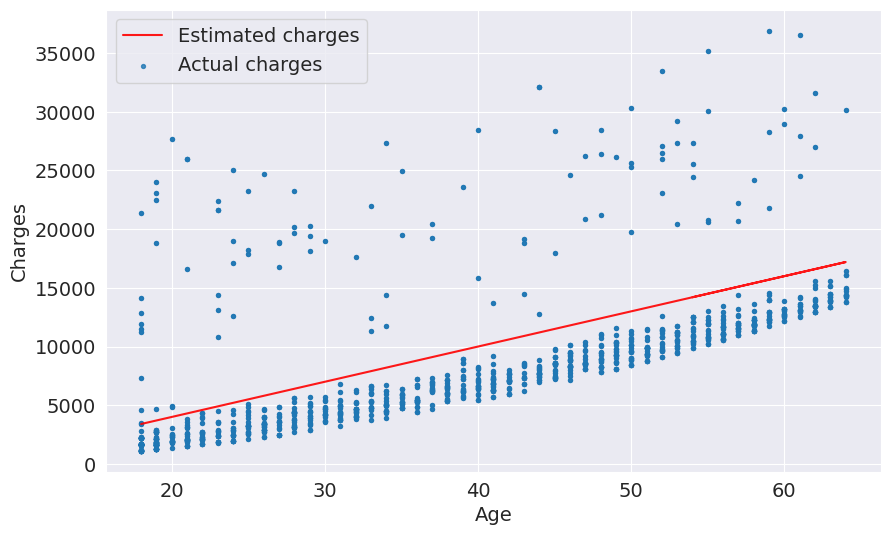

In [ ]:
try_parameters(300,-2000)

In [ ]:
print(non_smoker_df.columns)


Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')


In [ ]:
!pip install scikit-learn --quiet

In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
help(model.fit)
inputs = non_smoker_df[['age']]
targets = non_smoker_df.charges
print('inputs.shape: ',inputs.shape)
print('targets.shape: ',targets.shape)

Help on method fit in module sklearn.linear_model._base:

fit(X, y, sample_weight=None) method of sklearn.linear_model._base.LinearRegression instance
    Fit linear model.
    
    Parameters
    ----------
    X : {array-like, sparse matrix} of shape (n_samples, n_features)
        Training data.
    
    y : array-like of shape (n_samples,) or (n_samples, n_targets)
        Target values. Will be cast to X's dtype if necessary.
    
    sample_weight : array-like of shape (n_samples,), default=None
        Individual weights for each sample.
    
        .. versionadded:: 0.17
           parameter *sample_weight* support to LinearRegression.
    
    Returns
    -------
    self : object
        Fitted Estimator.

inputs.shape:  (2208, 1)
targets.shape:  (2208,)


In [ ]:
model.fit(inputs,targets)

LinearRegression()

In [ ]:
model.predict(np.array([[23],[37],[61]]))

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



array([ 4111.21547542,  7815.78585112, 14166.47792374])

In [ ]:
inputs.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2208 entries, 1 to 2771
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   age     2208 non-null   int64
dtypes: int64(1)
memory usage: 34.5 KB


In [ ]:
predictions = model.predict(inputs)
predictions


array([ 2788.15462696,  5434.27632388,  6757.33717235, ...,
        3581.99113603,  4111.21547542, 12314.19273589])

In [ ]:
model.coef_

array([264.61216969])

In [ ]:
model.intercept_

np.float64(-1974.8644275087008)

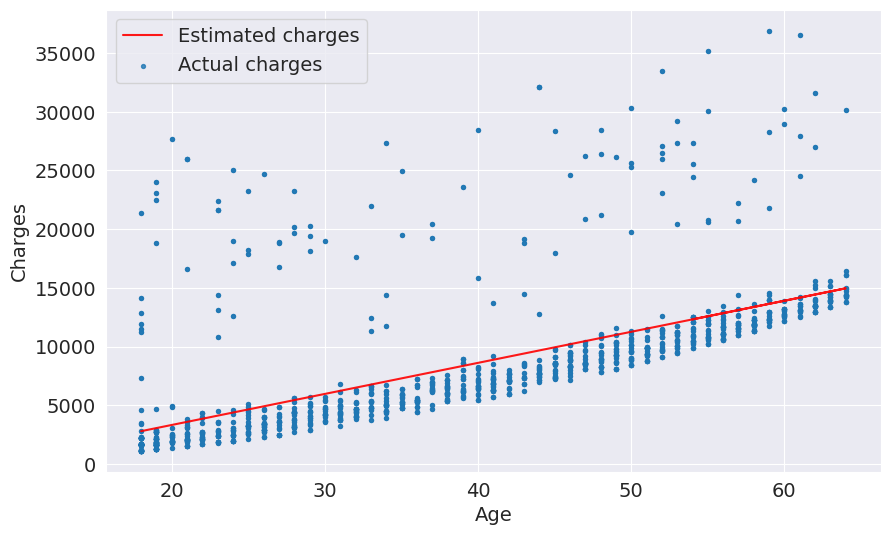

In [ ]:
try_parameters(model.coef_,model.intercept_)

In [ ]:
#machine learning part from here


# *******************************
#********************************
# *******************************

In [ ]:
inputs,targets= non_smoker_df[['age']],non_smoker_df['charges']
model = LinearRegression().fit(inputs,targets)
model.predict(inputs)
loss = rmse(targets,predictions)
print('LOSS: ',loss)

LOSS:  4714.536974891454


In [ ]:
jovian.commit()

[jovian] Detected Colab notebook...
[jovian] jovian.commit() is no longer required on Google Colab. If you ran this notebook from Jovian, 
then just save this file in Colab using Ctrl+S/Cmd+S and it will be updated on Jovian. 
Also, you can also delete this cell, it's no longer necessary.


In [ ]:
#adding bmi in prediction

inputs,targets= non_smoker_df[['age','bmi']],non_smoker_df['charges']
model = LinearRegression().fit(inputs,targets)
model.predict(inputs)
loss = rmse(targets,predictions)
print('LOSS: ',loss)
#bmi didn't create huge impact in loss lets mmove to other


LOSS:  4714.536974891454


In [ ]:
#lets check co relation with charges and bmi
non_smoker_df.charges.corr(non_smoker_df.bmi)

np.float64(0.07699235297055058)

In [ ]:
#their fore it has less relation we need to check with others
fig = px.scatter(non_smoker_df,x='bmi',y='charges',title ='BMI VS. Charges')
fig.update_traces(marker_size=5)
fig.show()

In [ ]:
model.coef_,model.intercept_ #close to before no chaange while adding bmi


(array([264.65603871,  -0.81289332]), np.float64(-1951.659403232361))

In [ ]:
non_smoker_df.charges.corr(non_smoker_df.children)

np.float64(0.13506718103134346)

In [ ]:
fig = px.strip(non_smoker_df,x ='children',y ='charges',title = 'Charges VS. Children')
fig.update_traces(marker_size = 3,marker_opacity=0.7)
fig.show()

In [ ]:
inputs,targets = non_smoker_df[['age','bmi','children']],non_smoker_df['charges']
model = LinearRegression().fit(inputs,targets)
model.predict(inputs)
loss = rmse(targets,predictions)
print('LOSS: ',loss)

LOSS:  4714.536974891454


In [ ]:
px.scatter(medical_df,x='age',y = 'charges',color='smoker')

In [ ]:
input,targets = medical_df[['age','bmi','children']],medical_df['charges']
model = LinearRegression().fit(input,targets)
model.predict(input)
loss = rmse(targets,predictions)
print('LOSS: ',loss)

LOSS:  4714.536974891454


In [ ]:
px.scatter(medical_df,x ='age',y='charges',color='smoker',title='AGE vs. CHARGEs')

<Axes: xlabel='smoker', ylabel='charges'>

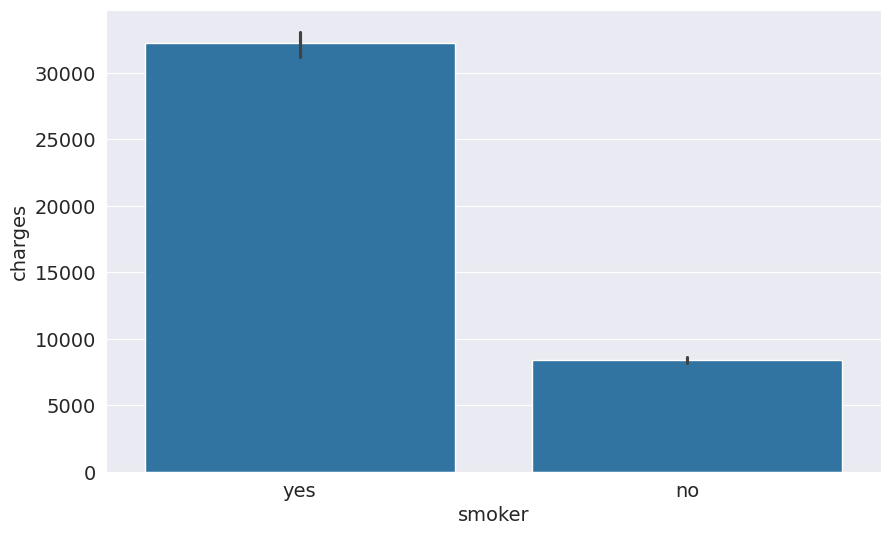

In [ ]:
sns.barplot(medical_df,x='smoker',y='charges')

In [ ]:
smoker_code = {'no':0,'yes':1}
medical_df['smoker_code'] = medical_df.smoker.map(smoker_code)

In [ ]:
medical_df.charges.corr(medical_df.smoker_code)

np.float64(0.7887833491419141)

In [ ]:
input,targets = medical_df[['age','bmi','children','smoker_code']],medical_df['charges']
model = LinearRegression().fit(input,targets)
model.predict(input)
loss = rmse(targets,predictions)
print('LOSS: ',loss)

LOSS:  4714.536974891454


np.float64(0.06283682831973217)

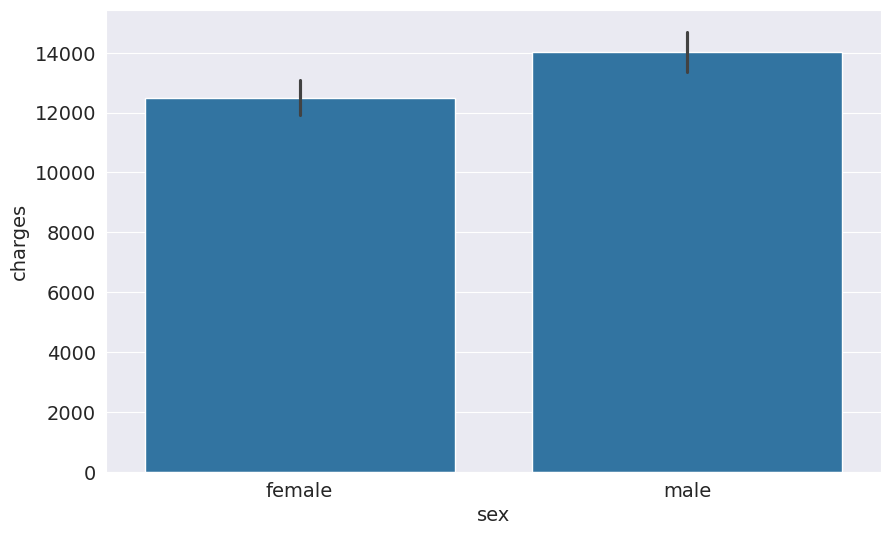

In [ ]:
sns.barplot(data=medical_df,x='sex',y='charges')
sex_codes = {'female': 0,'male':1}
medical_df['sex_codes']=medical_df.sex.map(sex_codes)
medical_df.charges.corr(medical_df.sex_codes)


In [ ]:
input,targets = medical_df[['age','bmi','children','smoker_code','sex_codes']],medical_df['charges']
model = LinearRegression().fit(input,targets)
model.predict(input)
loss = rmse(targets,predictions)
print('LOSS: ',loss)

LOSS:  4714.536974891454


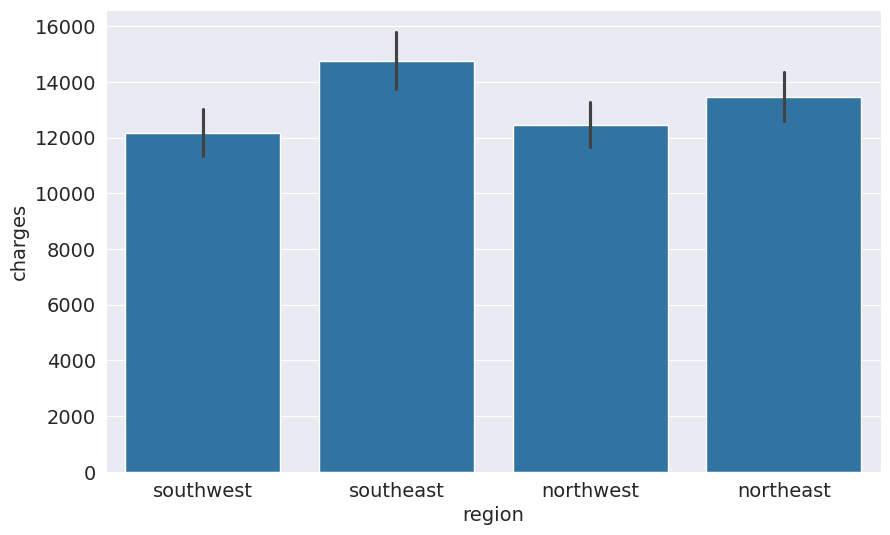

In [ ]:
# 4 categories are changed
sns.barplot(medical_df,x='region',y='charges');

In [ ]:
from sklearn import preprocessing
enc=preprocessing.OneHotEncoder()
enc.fit(medical_df[['region']])
enc.categories_


[array(['northeast', 'northwest', 'southeast', 'southwest'], dtype=object)]

In [ ]:
one_hot = enc.transform(medical_df[['region']]).toarray()
one_hot

array([[0., 0., 0., 1.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       ...,
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 0., 1.]])

In [ ]:
medical_df[['northeast','northwest','southeast','southwest']] = one_hot
medical_df

,age,sex,bmi,children,smoker,region,charges,smoker_code,sex_codes,northeast,northwest,southeast,southwest
0,19,female,27.900,0,yes,southwest,16884.92400,1,0,0.0,0.0,0.0,1.0
1,18,male,33.770,1,no,southeast,1725.55230,0,1,0.0,0.0,1.0,0.0
2,28,male,33.000,3,no,southeast,4449.46200,0,1,0.0,0.0,1.0,0.0
3,33,male,22.705,0,no,northwest,21984.47061,0,1,0.0,1.0,0.0,0.0
4,32,male,28.880,0,no,northwest,3866.85520,0,1,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2767,47,female,45.320,1,no,southeast,8569.86180,0,0,0.0,0.0,1.0,0.0
2768,21,female,34.600,0,no,southwest,2020.17700,0,0,0.0,0.0,0.0,1.0
2769,19,male,26.030,1,yes,northwest,16450.89470,1,1,0.0,1.0,0.0,0.0
2770,23,male,18.715,0,no,northwest,21595.38229,0,1,0.0,1.0,0.0,0.0


In [ ]:
model.coef_

array([  256.6182493 ,   311.82059256,   505.06135259, 23955.79834887,
         -56.53583572])

In [ ]:
model.intercept_

np.float64(-11750.087206178865)

In [ ]:
input_cols = medical_df[['age','bmi','children','smoker_code','sex_codes','northeast','northwest','southeast','southwest']]

In [ ]:
weights_df = pd.DataFrame({
    'features': np.append(input_cols, 'intercept'),
    'weight': np.append(model.coef_, model.intercept_)
})
weights_df

ValueError: All arrays must be of the same length

In [ ]:
from sklearn.preprocessing import StandardScaler
numeric_cols = ['age','bmi','children']
scaler =StandardScaler()
scaler.fit(medical_df[numeric_cols])



In [ ]:
scaler.mean_

In [ ]:
scaler.var_

In [ ]:
scaled_inputs = scaler.transform(medical_df[numeric_cols])
scaled_inputs

In [ ]:
cat_cols = ['smoker_code','sex_codes','northeast','northwest','southeast','southwest']
categorial_data = medical_df[cat_cols].values

In [ ]:
inputs =np.concatenate((scaled_inputs,categorial_data),axis = 1)
targets = medical_df.charges()
model = LinearRegression().fit(inputs,targets)
predictions = model.predict(inputs)
loss = rmse(targets,predictions)
print('LOSS: ',loss)

In [ ]:
model.coef_ = model.coef_[:0]
weight_df = pd.DataFrame({
    'features':np.append(numeric_cols,cat_cols),
    'weight':np.append(model.coef_,model.intercept_),
})
weight_df.sort_values('weight',ascending=False)


In [ ]:
from sklearn.model_selection import train_test_split
input_train,input_test,target_train,target_test = train_test_split(inputs,targets,test_size = 0.7962, random_state=42)

In [ ]:
model=LinearRegression().fit(input_train,target_train)
prediction_test = model.predict(input_test)
loss = rmse(target_test,prediction_test)
print("Test Loss: ",loss)

In [ ]:
#Done and dusted with loss
